<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/04_image_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Preprocessing

Before images can be used to train a deep learning model, they must be preprocessed into a consistent format. Images collected from different sources may vary in size, color channels, pixel ranges, and data types.

Image preprocessing prepares images by resizing them to a fixed resolution, normalizing pixel values, converting color spaces when required, and ensuring they match the input format expected by Convolutional Neural Networks (CNNs).

Proper preprocessing improves training stability, speeds up convergence, and helps models achieve better performance.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


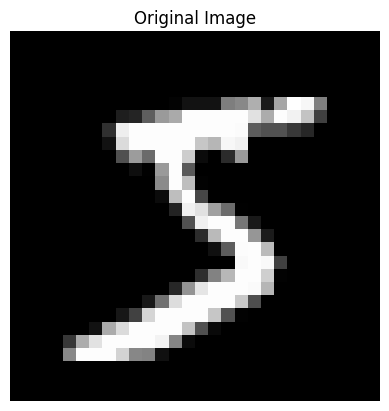

In [2]:
(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()

image = X_train[0]

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
print("Image Shape:", image.shape)

Image Shape: (28, 28)


In [4]:
normalized_image = image / 255.0

print("Minimum Pixel:", normalized_image.min())
print("Maximum Pixel:", normalized_image.max())

Minimum Pixel: 0.0
Maximum Pixel: 1.0


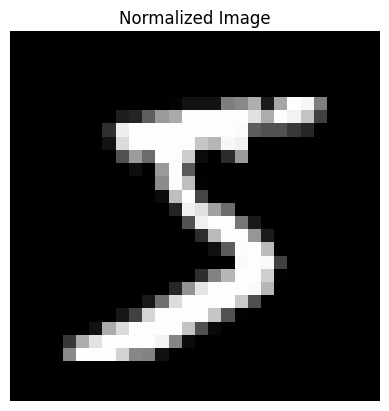

In [5]:
plt.imshow(normalized_image, cmap="gray")
plt.title("Normalized Image")
plt.axis("off")
plt.show()

In [6]:
resized_image = tf.image.resize(
    normalized_image[..., np.newaxis],
    (64,64)
)

print(resized_image.shape)

(64, 64, 1)


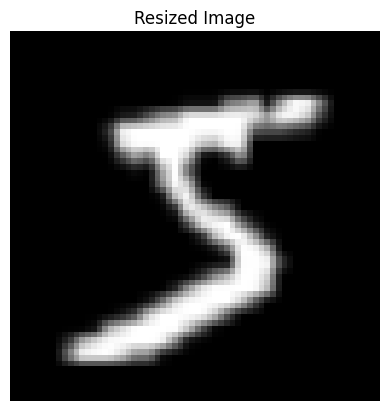

In [7]:
plt.imshow(resized_image[:,:,0], cmap="gray")
plt.title("Resized Image")
plt.axis("off")
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3065s 18us/step


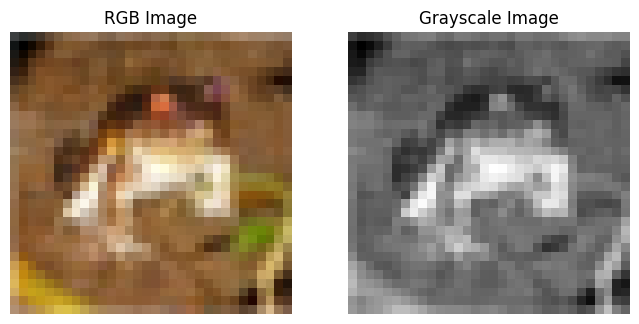

In [8]:
(X_cifar, y_cifar), _ = tf.keras.datasets.cifar10.load_data()

rgb_image = X_cifar[0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.axis("off")

gray = tf.image.rgb_to_grayscale(rgb_image)

plt.subplot(1,2,2)
plt.imshow(gray[:,:,0], cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

In [9]:
cnn_input = np.expand_dims(resized_image, axis=0)

print(cnn_input.shape)

(1, 64, 64, 1)


In [10]:
import pandas as pd

comparison = pd.DataFrame({

    "Step":[
        "Load Image",
        "Resize",
        "Normalize",
        "Convert Channels",
        "Batch Dimension"
    ],

    "Purpose":[
        "Read image",
        "Uniform size",
        "Scale pixels",
        "Required format",
        "Prepare for CNN"
    ]

})

comparison

,Step,Purpose
0,Load Image,Read image
1,Resize,Uniform size
2,Normalize,Scale pixels
3,Convert Channels,Required format
4,Batch Dimension,Prepare for CNN


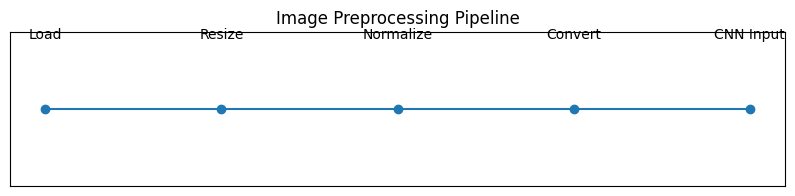

In [11]:
steps = [
    "Load",
    "Resize",
    "Normalize",
    "Convert",
    "CNN Input"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Image Preprocessing Pipeline")

plt.show()